In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from matplotlib.colors import TwoSlopeNorm


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)

sample_eddies = [100, 627, 1269, 2609, 34, 281, 2334, 3126]

dic_sample = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio_sample.pkl')
        

In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

# Unique colors for each eddy
colors = [c for i, c in enumerate(plt.get_cmap("tab10").colors) if i != 7]


In [4]:
def extremum_path(x1d, z2d, T2d, mode="max", z_level="median"):
    n, k = T2d.shape
    x_out = np.full(k, np.nan)
    z_out = np.full(k, np.nan)

    for kk in range(k):
        col = T2d[:, kk]
        zcol = z2d[:, kk]
        m = np.isfinite(col) & np.isfinite(zcol) & np.isfinite(x1d)

        if not np.any(m):
            continue

        ii = np.nanargmax(col[m]) if mode == "max" else np.nanargmin(col[m])
        idx = np.flatnonzero(m)[ii]

        x_out[kk] = x1d[idx]

        if z_level == "median":
            z_out[kk] = np.nanmedian(zcol[m])
        elif z_level == "mean":
            z_out[kk] = np.nanmean(zcol[m])
        else:
            z_out[kk] = zcol[idx]

    return x_out, z_out


def plot_temp_extrema(zlim=5):
    fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharey=True)

    fnumber_old = None
    temp_cache = {}
    wet = np.asarray(mask_rho).astype(bool)

    temp_ave = np.load("/srv/scratch/z5297792/Climatology/temp_ave_not_interpolated.npy")

    for e, (eddy, day_idx) in enumerate(zip(sample_eddies, day_idx_p)):

        ax0 = axs[e % 4, (e // 4) * 2]
        ax1 = axs[e % 4, 1 + (e // 4) * 2]

        r = 140 if eddy not in [1978, 1780] else 200

        cyc = df_eddies.loc[df_eddies.Eddy == eddy].iloc[0].Cyc

        dic = dic_sample[f"Eddy{eddy}"]
        day = list(dic.keys())[day_idx]
        df = dic[day].copy()

        rel_day = int(day[3:]) - df_eddies.loc[df_eddies.Eddy == eddy].iloc[0].Day

        ax0.set_title(f"{cyc}{eddy}, Day {rel_day}")
        ax1.set_title(f"{cyc}{eddy}, Day {rel_day}")

        day_int = int(day[3:])

        fname = df_eddies.loc[
            (df_eddies.Eddy == eddy) & (df_eddies.Day == day_int),
            "fname"
        ].iloc[0]

        fnumber = fname[-8:-3]

        if fnumber != fnumber_old:
            with nc.Dataset(fname) as dataset:
                ocean_time = dataset.variables["ocean_time"][:].data / 86400
            fnumber_old = fnumber

        t_rel = np.where(ocean_time == day_int)[0][0]

        if fname not in temp_cache:
            ds = nc.Dataset(fname)
            tempv = ds.variables["temp"]
            temp_arr = np.transpose(tempv, axes=(3, 2, 1, 0))
            temp_arr = np.flip(temp_arr, axis=2)
            temp_arr = np.where(wet[:, :, None, None], temp_arr, np.nan)
            temp_cache[fname] = temp_arr
            ds.close()

        temp_t = temp_cache[fname][:, :, :, t_rel].copy()
        temp_t -= temp_ave

        xc_surf, yc_surf = df.iloc[0].xc, df.iloc[0].yc

        ic = np.argmin(np.abs(x_grid - xc_surf))
        jc = np.argmin(np.abs(y_grid - yc_surf))

        x_mask = np.where(np.abs(x_grid - xc_surf) < r)[0]
        y_mask = np.where(np.abs(y_grid - yc_surf) < r)[0]

        mode = "max" if cyc == "AE" else "min"

        # x-z section
        T0 = temp_t[x_mask, jc, :]
        X0 = x_grid[x_mask]
        Z0 = np.abs(z_r[x_mask, jc, :]) / 1000

        vabs0 = np.nanmax(np.abs(T0))

        im0 = ax0.contourf(
            np.repeat(X0[:, None], T0.shape[1], axis=1),
            Z0,
            T0,
            cmap="coolwarm",
            norm=TwoSlopeNorm(vmin=-vabs0, vcenter=0, vmax=vabs0),
            zorder=0,
        )

        x_ext, z_ext = extremum_path(X0, Z0, T0, mode=mode)
        ax0.plot(x_ext, z_ext, color="k", lw=1.2, zorder=2)

        ax0.plot(df.xc, df.Depth.abs() / 1000, color=colors[e % len(colors)])

        root1_x, root2_x = [], []

        for k in range(len(df)):
            data = df.iloc[k]
            Q = data.Q

            root1, root2 = quad_solver_x(
                data.xc, data.yc,
                Q[0, 0], Q[1, 0], Q[1, 1],
                data.Rc,
                y_grid[jc]
            )

            root1_x.append(root1)
            root2_x.append(root2)

        ax0.plot(
            root1_x, df.Depth.abs() / 1e3,
            color=colors[e % len(colors)],
            ls="--",
            zorder=1 if df.iloc[-1].yc > y_grid[jc] else 3
        )

        ax0.plot(
            root2_x, df.Depth.abs() / 1e3,
            color=colors[e % len(colors)],
            ls="--",
            zorder=1 if df.iloc[-1].yc > y_grid[jc] else 3
        )

        ax0.set_xlabel("x (km)")
        ax0.set_ylabel("Depth (km)")
        ax0.plot(X0, h[x_mask, jc] / 1000, "k", zorder=2)
        ax0.fill_between(X0, h[x_mask, jc] / 1000, 10, color="k", zorder=2)

        cbar0 = fig.colorbar(im0, ax=ax0, orientation="vertical", pad=0.02, shrink=0.8)
        cbar0.set_label(r"TA [$^\circ$C]")

        # y-z section
        T1 = temp_t[ic, y_mask, :]
        Y1 = y_grid[y_mask]
        Z1 = np.abs(z_r[ic, y_mask, :]) / 1000

        vabs1 = np.nanmax(np.abs(T1))

        im1 = ax1.contourf(
            np.repeat(Y1[:, None], T1.shape[1], axis=1),
            Z1,
            T1,
            cmap="coolwarm",
            norm=TwoSlopeNorm(vmin=-vabs1, vcenter=0, vmax=vabs1),
            zorder=0,
        )

        y_ext, z_ext = extremum_path(Y1, Z1, T1, mode=mode)
        ax1.plot(y_ext, z_ext, color="k", lw=1.2, zorder=2)

        ax1.plot(df.yc, df.Depth.abs() / 1000, color=colors[e % len(colors)])

        root1_y, root2_y = [], []

        for k in range(len(df)):
            data = df.iloc[k]
            Q = data.Q

            root1, root2 = quad_solver_y(
                data.xc, data.yc,
                Q[0, 0], Q[1, 0], Q[1, 1],
                data.Rc,
                x_grid[ic]
            )

            root1_y.append(root1)
            root2_y.append(root2)

        ax1.plot(
            root1_y, df.Depth.abs() / 1e3,
            color=colors[e % len(colors)],
            ls="--",
            zorder=1 if df.iloc[-1].xc < x_grid[ic] else 3
        )

        ax1.plot(
            root2_y, df.Depth.abs() / 1e3,
            color=colors[e % len(colors)],
            ls="--",
            zorder=1 if df.iloc[-1].xc < x_grid[ic] else 3
        )

        ax1.set_xlabel("y (km)")
        ax1.plot(Y1, h[ic, y_mask] / 1000, "k", zorder=2)
        ax1.fill_between(Y1, h[ic, y_mask] / 1000, 10, color="k", zorder=2)
        ax1.set_ylim(0, zlim)

        cbar1 = fig.colorbar(im1, ax=ax1, orientation="vertical", pad=0.02, shrink=0.8)
        cbar1.set_label(r"TA ($^\circ$C)")

    axs[0, 0].invert_yaxis()
    plt.tight_layout()
    plt.show()
    

In [5]:
def quad_solver_x(xc, yc, q11, q12, q22, Rc, y0):
    a = q11
    b = -2*q11*xc + 2*q12*(y0 - yc)
    c = q11*xc**2 - 2*q12*xc*(y0 - yc) + q22*(y0 - yc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return root1, root2

def quad_solver_y(xc, yc, q11, q12, q22, Rc, x0):
    a = q22
    b = 2*q12*(x0 - xc)
    c = q11*(x0 - xc)**2 - Rc**2/2

    disc = b*b - 4*a*c
    dy1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
    dy2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)
    return yc + dy1, yc + dy2
    

In [6]:
day_idx_p = [26, 17, 5, 51, 
             68, 89, 114, 40]

/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_996880/1326891384.py:7: RuntimeWarning: invalid value encountered in sqrt
  root1 = np.where(disc >= 0, (-b - np.sqrt(disc)) / (2*a), np.nan)
/scratch/pbs.8058111.kman.restech.unsw.edu.au/ipykernel_996880/1326891384.py:8: RuntimeWarning: invalid value encountered in sqrt
  root2 = np.where(disc >= 0, (-b + np.sqrt(disc)) / (2*a), np.nan)


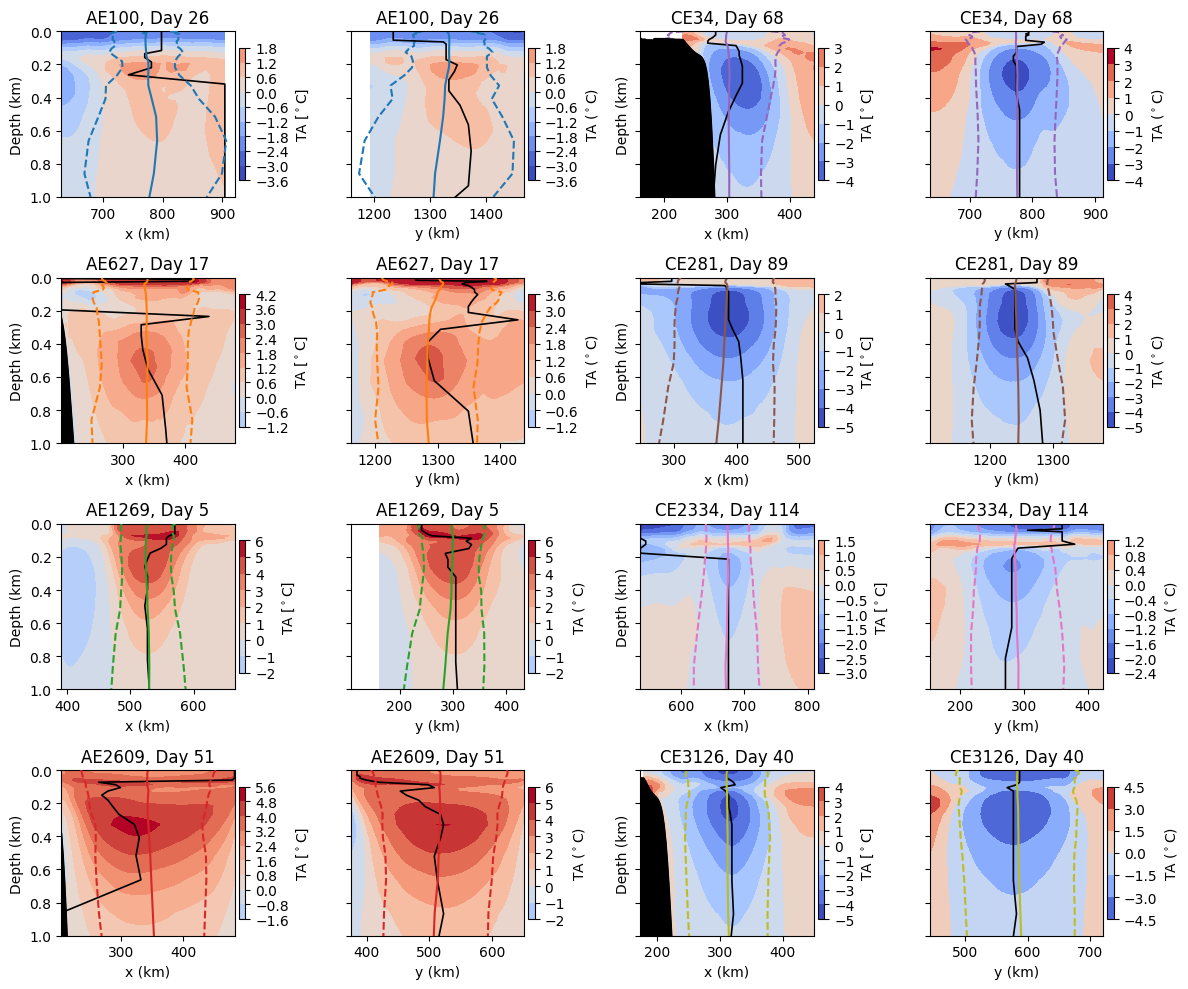

In [7]:
plot_temp_extrema(zlim=1)
